# 04. Baseline Retrieval

기준 향수 하나가 주어졌을 때 향 구조 기반 알고리즘이 사용자들이 비슷하다고 평가한 향수를 TOP-K 안에서 얼마나 잘 찾아내는지 평가한다.

## 분석 목적

- `reminds_me_of`를 Negative 분류 데이터가 아니라 **Relevant Item** 데이터로 재정의한다.
- Accord 기반 유사도 추천 성능을 측정한다.
- Note 기반 유사도 추천 성능을 측정한다.
- 단순 Accord + Note 복합 방식의 성능을 측정한다.
- 개인화나 향 유사성을 사용하지 않는 Popularity Baseline과 비교한다.
- 향 구조 데이터만으로 실제 사용자 향 유사성 판단을 얼마나 재현할 수 있는지 확인한다.

이번 실험은 최종 추천 모델을 결정하는 단계가 아니라 **Baseline 비교 실험**이다. `reminds_me_of`는 유사도 계산에 사용하지 않고 오직 평가 label로만 사용한다. 평가 label은 사용자 투표에서 얻은 불완전한 implicit relevance label이며 절대적인 Ground Truth가 아니다.

## 1. 환경 설정

JSONL 전체를 DataFrame으로 복제하지 않는다. 필요한 scalar, sparse matrix triplet, 관계 투표만 한 번의 스트리밍으로 수집한다. 모든 무작위 추출은 seed 42를 사용한다.

In [1]:
import array
import collections
import gc
import json
import math
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import sparse

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        # tqdm이 없는 환경에서도 같은 분석이 실행되게 하는 fallback
        return iterable

SEED = 42
TOP_KS = (5, 10, 20, 50)
MAX_K = max(TOP_KS)
BATCH_SIZE = 32

jsonl_path = pathlib.Path.cwd() / "perfumes.jsonl"
assert jsonl_path.is_file(), f"파일을 찾을 수 없습니다: {jsonl_path}"

print(f"데이터: {jsonl_path.name}")
print(f"크기: {jsonl_path.stat().st_size / (1024 ** 2):,.2f} MB")

데이터: perfumes.jsonl
크기: 485.94 MB


## 2. 데이터 로드

향수별 `id`, `name`, `brand`, Accord strength, top/middle/base/flat Note의 union, `popularity.magnitude`, `similar.reminds_me_of`만 수집한다. Note 위치 정보는 읽되 이 Baseline에서는 위치를 구분하지 않는다.

In [2]:
perfume_ids = array.array("i")
perfume_names = []
perfume_brands = []
popularity_values = array.array("f")
has_accord = array.array("b")
has_note = array.array("b")

accord_to_col = {}
accord_rows = array.array("I")
accord_cols = array.array("I")
accord_data = array.array("f")

note_to_col = {}
note_rows = array.array("I")
note_cols = array.array("I")

relation_source_ids = array.array("i")
relation_target_ids = array.array("i")
relation_up_votes = array.array("i")
relation_down_votes = array.array("i")

with jsonl_path.open("r", encoding="utf-8") as file:
    for line in tqdm(file, desc="JSONL load", unit=" perfumes"):
        if not line.strip():
            continue
        row_index = len(perfume_ids)
        record = json.loads(line)
        perfume_id = int(record["id"])
        perfume_ids.append(perfume_id)
        perfume_names.append(record.get("name") or "")
        perfume_brands.append(record.get("brand") or "")

        magnitude = (record.get("popularity") or {}).get("magnitude")
        popularity_values.append(float(magnitude) if magnitude is not None else np.nan)

        # 같은 향수 안에서 Accord 이름이 중복되면 마지막 값을 사용한다.
        accord_strengths = {}
        for item in record.get("accords") or []:
            name = item.get("name")
            strength = item.get("strength")
            if name and strength is not None:
                col = accord_to_col.setdefault(name, len(accord_to_col))
                accord_strengths[col] = float(strength)
        has_accord.append(bool(accord_strengths))
        for col, strength in accord_strengths.items():
            accord_rows.append(row_index)
            accord_cols.append(col)
            accord_data.append(strength)

        notes = record.get("notes") or {}
        tiered = notes.get("tiered") or {}
        note_names = set()
        for position in ("top", "middle", "base"):
            note_names.update(
                item.get("name")
                for item in tiered.get(position) or []
                if item.get("name")
            )
        note_names.update(
            item.get("name")
            for item in notes.get("flat") or []
            if item.get("name")
        )
        note_columns = {
            note_to_col.setdefault(name, len(note_to_col))
            for name in note_names
        }
        has_note.append(bool(note_columns))
        for col in note_columns:
            note_rows.append(row_index)
            note_cols.append(col)

        for relation in (record.get("similar") or {}).get("reminds_me_of") or []:
            target_id = relation.get("id")
            up_votes = relation.get("up_votes")
            down_votes = relation.get("down_votes")
            relation_source_ids.append(perfume_id)
            relation_target_ids.append(int(target_id) if target_id is not None else -1)
            relation_up_votes.append(int(up_votes) if up_votes is not None else -1)
            relation_down_votes.append(int(down_votes) if down_votes is not None else -1)

perfume_ids = np.asarray(perfume_ids, dtype=np.int32)
popularity = np.asarray(popularity_values, dtype=np.float32)
has_accord = np.asarray(has_accord, dtype=bool)
has_note = np.asarray(has_note, dtype=bool)
id_to_row = {int(perfume_id): row for row, perfume_id in enumerate(perfume_ids)}
n_perfumes = len(perfume_ids)

print(f"향수 수: {n_perfumes:,}")
print(f"고유 Accord 수: {len(accord_to_col):,}")
print(f"고유 Note 수: {len(note_to_col):,}")
print(f"directed reminds_me_of 수: {len(relation_source_ids):,}")
if len(accord_to_col) != 92:
    print(f"주의: 현재 파일에서 관측된 Accord는 92개가 아니라 {len(accord_to_col):,}개입니다.")

향수 수: 131,930
고유 Accord 수: 92
고유 Note 수: 2,523
directed reminds_me_of 수: 692,729


## 3. Relevant Pair 구축

`reminds_me_of`의 A→B, B→A를 `(min(source_id, target_id), max(source_id, target_id))` unordered pair로 합치고 양방향의 up/down votes를 합산한다.

후보 기준은 `total_votes >= 20 AND agree_ratio >= 0.8`이다. 이는 현재 EDA에서 사용하는 신뢰도 기준일 뿐 절대적인 Ground Truth가 아니다. 데이터셋 밖 ID가 포함된 pair는 전체 후보 규모에는 포함하지만, 검색으로 반환할 수 없으므로 평가용 관계에서는 제외한다.

In [3]:
directed_relations = pd.DataFrame({
    "source_id": np.asarray(relation_source_ids, dtype=np.int32),
    "target_id": np.asarray(relation_target_ids, dtype=np.int32),
    "up_votes": np.asarray(relation_up_votes, dtype=np.int32),
    "down_votes": np.asarray(relation_down_votes, dtype=np.int32),
})

valid = directed_relations[
    (directed_relations["source_id"] > 0)
    & (directed_relations["target_id"] > 0)
    & (directed_relations["up_votes"] >= 0)
    & (directed_relations["down_votes"] >= 0)
].copy()
valid["pair_low"] = np.minimum(valid["source_id"], valid["target_id"])
valid["pair_high"] = np.maximum(valid["source_id"], valid["target_id"])

pair_relations = (
    valid.groupby(["pair_low", "pair_high"], sort=False, as_index=False)
    [["up_votes", "down_votes"]]
    .sum()
)
pair_relations["total_votes"] = pair_relations["up_votes"] + pair_relations["down_votes"]
pair_relations["agree_ratio"] = np.divide(
    pair_relations["up_votes"],
    pair_relations["total_votes"],
    out=np.full(len(pair_relations), np.nan),
    where=pair_relations["total_votes"].to_numpy() > 0,
)

relevant_pairs_all = pair_relations[
    (pair_relations["pair_low"] != pair_relations["pair_high"])
    & (pair_relations["total_votes"] >= 20)
    & (pair_relations["agree_ratio"] >= 0.8)
][["pair_low", "pair_high", "total_votes", "agree_ratio"]].copy()

unique_relevant_perfumes = pd.unique(
    relevant_pairs_all[["pair_low", "pair_high"]].to_numpy().ravel()
)
inside_mask = (
    relevant_pairs_all["pair_low"].isin(id_to_row)
    & relevant_pairs_all["pair_high"].isin(id_to_row)
)
relevant_pairs = relevant_pairs_all.loc[inside_mask].copy()

pd.Series({
    "전체 Relevant Pair 수": len(relevant_pairs_all),
    "Relevant Pair에 등장하는 고유 향수 수": len(unique_relevant_perfumes),
    "데이터셋 내부 Relevant Pair 수": len(relevant_pairs),
    "데이터셋 밖 ID를 포함해 평가에서 제외된 Pair 수": int((~inside_mask).sum()),
}).to_frame("값")

# 관계 집계가 끝난 대용량 directed 중간 객체는 즉시 해제한다.
del directed_relations, valid, pair_relations
del relation_source_ids, relation_target_ids, relation_up_votes, relation_down_votes
gc.collect()

20

## 4. Query별 Relevant Item 구성

향수 유사성을 대칭으로 취급한다. A-B가 Relevant Pair이면 A의 relevant set에 B를, B의 relevant set에 A를 넣는다.

In [4]:
relevant_by_query = collections.defaultdict(set)
for pair_low, pair_high in relevant_pairs[["pair_low", "pair_high"]].itertuples(index=False, name=None):
    low = int(pair_low)
    high = int(pair_high)
    relevant_by_query[low].add(high)
    relevant_by_query[high].add(low)

relevant_counts = pd.Series(
    {query_id: len(items) for query_id, items in relevant_by_query.items()},
    name="relevant_item_count",
    dtype="int32",
)

del relevant_pairs, relevant_pairs_all
gc.collect()

summary = relevant_counts.describe(percentiles=[0.25, 0.5, 0.75])
pd.Series({
    "query 수": int(summary["count"]),
    "relevant item 개수 평균": summary["mean"],
    "중앙값": summary["50%"],
    "25%": summary["25%"],
    "75%": summary["75%"],
    "최대": summary["max"],
}).to_frame("값")

,값
query 수,12150.00000
relevant item 개수 평균,1.77284
중앙값,1.00000
25%,1.00000
75%,2.00000
최대,104.00000


,query 수
relevant items >= 1,12150
relevant items >= 2,3856
relevant items >= 3,1764
relevant items >= 5,591
relevant items >= 10,136


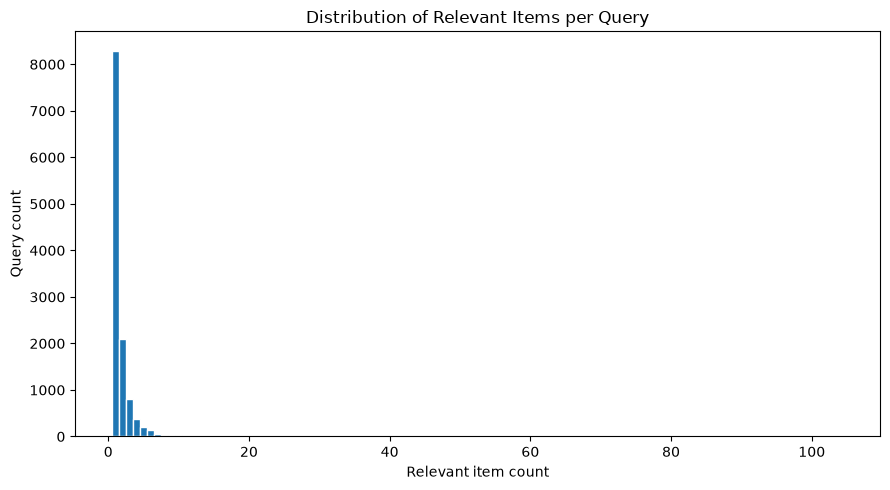

In [5]:
threshold_summary = pd.Series({
    f"relevant items >= {threshold}": int((relevant_counts >= threshold).sum())
    for threshold in (1, 2, 3, 5, 10)
})
display(threshold_summary.to_frame("query 수"))

plt.figure(figsize=(9, 5))
bins = np.arange(0.5, relevant_counts.max() + 1.5)
plt.hist(relevant_counts, bins=bins, edgecolor="white")
plt.title("Distribution of Relevant Items per Query")
plt.xlabel("Relevant item count")
plt.ylabel("Query count")
plt.tight_layout()
plt.show()

## 5. 평가 Query Set 구성

relevant item이 2개 이상이고 Accord와 Note가 모두 기록된 query만 사용한다. 1,000개 이상이면 seed 42로 1,000개를 무작위 추출한 뒤 Development 700개와 Final Holdout 300개로 분리한다. 1,000개 미만이면 조건을 완화하지 않고 가능한 query만 70:30으로 분리한다.

**이후 모든 추천 생성과 성능 계산은 Development Query에 대해서만 수행한다. Final Holdout은 향후 최종 로직 결정 후 한 번만 평가하기 위해 보존한다.**

In [6]:
eligible_query_ids = np.array(sorted(
    query_id
    for query_id, items in relevant_by_query.items()
    if len(items) >= 2
    and has_accord[id_to_row[query_id]]
    and has_note[id_to_row[query_id]]
), dtype=np.int32)

print(f"평가 조건을 만족하는 query 수: {len(eligible_query_ids):,}")

selection_rng = np.random.default_rng(SEED)
if len(eligible_query_ids) >= 1000:
    selected_query_ids = selection_rng.choice(eligible_query_ids, size=1000, replace=False)
else:
    selected_query_ids = eligible_query_ids.copy()
    print("조건을 만족하는 query가 1,000개 미만이므로 조건을 완화하지 않습니다.")

split_rng = np.random.default_rng(SEED)
selected_query_ids = split_rng.permutation(selected_query_ids)
if len(selected_query_ids) == 1000:
    n_development = 700
elif len(selected_query_ids) <= 1:
    n_development = len(selected_query_ids)
else:
    n_development = min(len(selected_query_ids) - 1, max(1, round(len(selected_query_ids) * 0.7)))

development_query_ids = selected_query_ids[:n_development]
final_holdout_query_ids = selected_query_ids[n_development:]

assert set(development_query_ids).isdisjoint(final_holdout_query_ids)
print(f"선택된 query 수: {len(selected_query_ids):,}")
print(f"Development query 수: {len(development_query_ids):,}")
print(f"Final Holdout query 수: {len(final_holdout_query_ids):,}")
print("Final Holdout에서는 추천 생성과 성능 계산을 수행하지 않습니다.")

평가 조건을 만족하는 query 수: 3,835
선택된 query 수: 1,000
Development query 수: 700
Final Holdout query 수: 300
Final Holdout에서는 추천 생성과 성능 계산을 수행하지 않습니다.


## 6. 평가 데이터 편향 확인

Development Query와 relevant item이 1개 이상인 전체 Relevant Query의 relevant item 수 및 popularity magnitude 평균·중앙값을 비교한다.

In [7]:
def query_distribution_summary(query_ids, label):
    counts = np.array([len(relevant_by_query[int(q)]) for q in query_ids], dtype=float)
    magnitudes = np.array([popularity[id_to_row[int(q)]] for q in query_ids], dtype=float)
    return {
        "query_set": label,
        "query_count": len(query_ids),
        "relevant_count_mean": np.nanmean(counts),
        "relevant_count_median": np.nanmedian(counts),
        "popularity_mean": np.nanmean(magnitudes),
        "popularity_median": np.nanmedian(magnitudes),
    }

all_relevant_query_ids = np.array(sorted(relevant_by_query), dtype=np.int32)
bias_comparison = pd.DataFrame([
    query_distribution_summary(all_relevant_query_ids, "All Relevant Query"),
    query_distribution_summary(development_query_ids, "Development Query"),
])
bias_comparison.round(2)

,query_set,query_count,relevant_count_mean,relevant_count_median,popularity_mean,popularity_median
0,All Relevant Query,12150,1.77,1.0,4202.61,976.0
1,Development Query,700,3.40,2.0,8757.60,2399.5


## 7. Accord Vector와 Note Set 생성

전체 고유 Accord(현재 데이터에서 기대되는 92개)를 열로 하는 sparse strength matrix를 만든다. 값은 0~100이다.

> 0은 해당 Accord가 향에 절대 존재하지 않는다는 의미가 아니라 주요 Accord 목록에 기록되지 않았음을 의미할 수 있다.

Note는 top/middle/base/flat 위치를 구분하지 않은 union set으로 binary sparse matrix를 만든다. 이번 단계에서는 Note 위치 가중치를 적용하지 않는다.

In [8]:
X_accord = sparse.csr_matrix(
    (
        np.asarray(accord_data, dtype=np.float32),
        (np.asarray(accord_rows, dtype=np.int32), np.asarray(accord_cols, dtype=np.int32)),
    ),
    shape=(n_perfumes, len(accord_to_col)),
    dtype=np.float32,
)
X_notes = sparse.csr_matrix(
    (
        np.ones(len(note_rows), dtype=np.int16),
        (np.asarray(note_rows, dtype=np.int32), np.asarray(note_cols, dtype=np.int32)),
    ),
    shape=(n_perfumes, len(note_to_col)),
    dtype=np.int16,
)

accord_norms = np.sqrt(X_accord.multiply(X_accord).sum(axis=1)).A1
inverse_norms = np.zeros_like(accord_norms, dtype=np.float32)
np.divide(1.0, accord_norms, out=inverse_norms, where=accord_norms > 0)
X_accord_normalized = X_accord.multiply(inverse_norms[:, None]).tocsr()
note_counts = np.asarray(X_notes.sum(axis=1)).ravel().astype(np.int32)

print(f"Accord matrix: {X_accord.shape}, nnz={X_accord.nnz:,}, dtype={X_accord.dtype}")
print(f"Note matrix: {X_notes.shape}, nnz={X_notes.nnz:,}, dtype={X_notes.dtype}")

# sparse matrix 생성 후 중복되는 triplet 원시 배열을 해제한다.
del accord_rows, accord_cols, accord_data, note_rows, note_cols
del X_accord
gc.collect()

Accord matrix: (131930, 92), nnz=1,000,570, dtype=float32
Note matrix: (131930, 2523), nnz=1,091,811, dtype=int16


8255

## 8. Baseline 추천 생성

- **Popularity**: 모든 query에 동일한 popularity 순위(자기 자신 제외)를 사용한다.
- **Accord Cosine**: 정규화된 sparse Accord 행렬의 내적으로 cosine similarity를 구한다.
- **Note Jaccard**: sparse binary Note 행렬의 내적으로 교집합을 구하고 `intersection / union`을 계산한다.
- **Accord + Note**: `0.5 * accord_cosine + 0.5 * note_jaccard`를 사용한다.

0.5 / 0.5는 최종 가중치가 아니라 두 정보를 동일 비중으로 결합한 초기 Baseline이다. 전체 N×N 행렬은 만들지 않는다. Development Query를 작은 batch로 계산하고 각 query의 TOP 50만 남긴다. 점수가 같은 후보는 향수 ID 오름차순으로 정렬한다.

In [9]:
def top_k_rows(score_vector, k=MAX_K):
    k = min(k, score_vector.size - 1)
    candidate_rows = np.argpartition(-score_vector, kth=k - 1)[:k]
    order = np.lexsort((perfume_ids[candidate_rows], -score_vector[candidate_rows]))
    return candidate_rows[order].astype(np.int32, copy=False)


rankings = {
    "Popularity": {},
    "Accord Cosine": {},
    "Note Jaccard": {},
    "Accord + Note": {},
}

popularity_for_sort = np.nan_to_num(popularity, nan=-np.inf)
global_popularity_rows = np.lexsort((perfume_ids, -popularity_for_sort))
for query_id in development_query_ids:
    query_id = int(query_id)
    query_row = id_to_row[query_id]
    rows = global_popularity_rows[global_popularity_rows != query_row][:MAX_K]
    rankings["Popularity"][query_id] = rows.astype(np.int32, copy=False)

print(f"Popularity TOP {MAX_K} 생성 완료: {len(rankings['Popularity']):,} queries")

Popularity TOP 50 생성 완료: 700 queries


In [10]:
development_rows = np.array(
    [id_to_row[int(query_id)] for query_id in development_query_ids],
    dtype=np.int32,
)

for start in tqdm(range(0, len(development_rows), BATCH_SIZE), desc="Structure baselines"):
    query_rows = development_rows[start:start + BATCH_SIZE]
    query_ids = development_query_ids[start:start + BATCH_SIZE]

    # batch × N만 잠시 생성하며 N × N 행렬은 생성하지 않는다.
    accord_scores = (X_accord_normalized[query_rows] @ X_accord_normalized.T).toarray()
    intersections = (X_notes[query_rows] @ X_notes.T).toarray()
    unions = note_counts[query_rows, None] + note_counts[None, :] - intersections
    note_scores = np.zeros(intersections.shape, dtype=np.float32)
    np.divide(intersections, unions, out=note_scores, where=unions > 0)
    combined_scores = 0.5 * accord_scores + 0.5 * note_scores

    for local_index, (query_id, query_row) in enumerate(zip(query_ids, query_rows)):
        query_id = int(query_id)
        accord_scores[local_index, query_row] = -np.inf
        note_scores[local_index, query_row] = -np.inf
        combined_scores[local_index, query_row] = -np.inf
        rankings["Accord Cosine"][query_id] = top_k_rows(accord_scores[local_index])
        rankings["Note Jaccard"][query_id] = top_k_rows(note_scores[local_index])
        rankings["Accord + Note"][query_id] = top_k_rows(combined_scores[local_index])

    del accord_scores, intersections, unions, note_scores, combined_scores

print(f"향 구조 TOP {MAX_K} 생성 완료: {len(development_query_ids):,} Development queries")
print(f"Holdout 추천 생성 수: {sum(int(q in rankings['Accord + Note']) for q in final_holdout_query_ids)}")

향 구조 TOP 50 생성 완료: 700 Development queries
Holdout 추천 생성 수: 0


## 9. 평가 지표

모든 지표는 Development Query별로 계산한 뒤 평균한다.

- Recall@K: 전체 known relevant item 중 TOP-K에서 찾은 비율
- Precision@K: TOP-K 중 known relevant item 비율
- Hit Rate@K: TOP-K에 known relevant item이 하나라도 있으면 1
- MRR@K: 첫 번째 relevant item의 reciprocal rank
- NDCG@K: binary relevance 기반 normalized discounted cumulative gain

`reminds_me_of`가 실제 유사 향수를 완전히 라벨링하지 않았을 수 있으므로 Precision은 보조 지표로만 해석한다. 결과 해석은 Recall, Hit Rate, MRR, NDCG를 중심으로 한다.

In [11]:
def query_metrics(recommended_rows, relevant_ids, k):
    recommended_ids = perfume_ids[recommended_rows[:k]]
    relevance = np.fromiter(
        (int(candidate_id) in relevant_ids for candidate_id in recommended_ids),
        dtype=np.int8,
        count=len(recommended_ids),
    )
    hits = int(relevance.sum())
    recall = hits / len(relevant_ids)
    precision = hits / k
    hit_rate = float(hits > 0)
    hit_positions = np.flatnonzero(relevance)
    mrr = 1.0 / (hit_positions[0] + 1) if hit_positions.size else 0.0
    discounts = 1.0 / np.log2(np.arange(2, len(relevance) + 2))
    dcg = float(np.dot(relevance, discounts))
    ideal_length = min(len(relevant_ids), k)
    idcg = float(discounts[:ideal_length].sum())
    ndcg = dcg / idcg if idcg > 0 else 0.0
    return {
        "recall": recall,
        "precision": precision,
        "hit_rate": hit_rate,
        "mrr": mrr,
        "ndcg": ndcg,
    }


per_query_metrics = collections.defaultdict(dict)
metric_means = {}

for model_name, model_rankings in rankings.items():
    aggregate = collections.defaultdict(list)
    for query_id in development_query_ids:
        query_id = int(query_id)
        relevant_ids = relevant_by_query[query_id]
        for k in TOP_KS:
            values = query_metrics(model_rankings[query_id], relevant_ids, k)
            per_query_metrics[model_name][(query_id, k)] = values
            for metric_name, value in values.items():
                aggregate[(metric_name, k)].append(value)
    metric_means[model_name] = {
        key: float(np.mean(values)) for key, values in aggregate.items()
    }

print(f"평가한 Development query 수: {len(development_query_ids):,}")
print("Final Holdout metric은 계산하지 않았습니다.")

평가한 Development query 수: 700
Final Holdout metric은 계산하지 않았습니다.


## 10. 결과 비교표

성능이 높은 모델을 자동으로 "최종 모델"로 결정하지 않고 결과만 비교한다.

In [12]:
result_rows = []
for model_name in ("Popularity", "Accord Cosine", "Note Jaccard", "Accord + Note"):
    means = metric_means[model_name]
    result_rows.append({
        "model": model_name,
        "Recall@5": means[("recall", 5)],
        "Recall@10": means[("recall", 10)],
        "Recall@20": means[("recall", 20)],
        "Recall@50": means[("recall", 50)],
        "HitRate@5": means[("hit_rate", 5)],
        "HitRate@10": means[("hit_rate", 10)],
        "HitRate@20": means[("hit_rate", 20)],
        "HitRate@50": means[("hit_rate", 50)],
        "MRR@10": means[("mrr", 10)],
        "MRR@50": means[("mrr", 50)],
        "NDCG@10": means[("ndcg", 10)],
        "NDCG@20": means[("ndcg", 20)],
        "Precision@10": means[("precision", 10)],
    })

results_df = pd.DataFrame(result_rows)
results_df.round(4)

,model,Recall@5,Recall@10,Recall@20,Recall@50,HitRate@5,HitRate@10,HitRate@20,HitRate@50,MRR@10,MRR@50,NDCG@10,NDCG@20,Precision@10
0,Popularity,0.0098,0.0167,0.0228,0.0364,0.0300,0.0443,0.0600,0.1000,0.0163,0.0187,0.0113,0.0132,0.0050
1,Accord Cosine,0.1466,0.1868,0.2232,0.2777,0.3443,0.4071,0.4543,0.5143,0.2564,0.2616,0.1688,0.1808,0.0596
2,Note Jaccard,0.2137,0.2545,0.2951,0.3587,0.4400,0.5029,0.5471,0.6100,0.3382,0.3434,0.2345,0.2492,0.0751
3,Accord + Note,0.2400,0.2900,0.3455,0.4098,0.4871,0.5500,0.6100,0.6657,0.3806,0.3864,0.2668,0.2867,0.0869


## 11. Popularity 대비 성능 개선폭

향 기반 세 모델에 대해 absolute improvement와 relative improvement(%)를 계산한다. Popularity 값이 0이면 relative improvement는 NaN이다.

In [13]:
improvement_metrics = ["Recall@10", "Recall@20", "HitRate@10", "MRR@10", "NDCG@10"]
popularity_result = results_df.set_index("model").loc["Popularity"]
improvement_rows = []

for model_name in ("Accord Cosine", "Note Jaccard", "Accord + Note"):
    model_result = results_df.set_index("model").loc[model_name]
    for metric_name in improvement_metrics:
        baseline_value = float(popularity_result[metric_name])
        model_value = float(model_result[metric_name])
        absolute = model_value - baseline_value
        relative = np.nan if baseline_value == 0 else absolute / baseline_value * 100
        improvement_rows.append({
            "model": model_name,
            "metric": metric_name,
            "popularity": baseline_value,
            "model_value": model_value,
            "absolute_improvement": absolute,
            "relative_improvement_%": relative,
        })

improvement_df = pd.DataFrame(improvement_rows)
improvement_df.round(4)

,model,metric,popularity,model_value,absolute_improvement,relative_improvement_%
0,Accord Cosine,Recall@10,0.0167,0.1868,0.1701,1016.6056
1,Accord Cosine,Recall@20,0.0228,0.2232,0.2003,878.2749
2,Accord Cosine,HitRate@10,0.0443,0.4071,0.3629,819.3548
3,Accord Cosine,MRR@10,0.0163,0.2564,0.2401,1472.7361
4,Accord Cosine,NDCG@10,0.0113,0.1688,0.1575,1392.7782
5,Note Jaccard,Recall@10,0.0167,0.2545,0.2378,1421.3002
6,Note Jaccard,Recall@20,0.0228,0.2951,0.2723,1193.8788
7,Note Jaccard,HitRate@10,0.0443,0.5029,0.4586,1035.4839
8,Note Jaccard,MRR@10,0.0163,0.3382,0.3219,1974.4262
9,Note Jaccard,NDCG@10,0.0113,0.2345,0.2232,1974.0803


## 12. Query별 비교

Development Query 중 seed 42로 최대 10개를 무작위 선택해 실제 Relevant 목록과 세 향 구조 모델의 TOP 5를 확인한다. `is_relevant`는 현재 implicit label 기준이다.

In [14]:
def perfume_label(perfume_id):
    row = id_to_row[int(perfume_id)]
    return f"{perfume_names[row]} — {perfume_brands[row]}"


def recommendation_table(query_id, model_name, k=5):
    relevant_ids = relevant_by_query[int(query_id)]
    rows = rankings[model_name][int(query_id)][:k]
    return pd.DataFrame({
        "rank": np.arange(1, len(rows) + 1),
        "perfume": [perfume_names[row] for row in rows],
        "brand": [perfume_brands[row] for row in rows],
        "is_relevant": [int(perfume_ids[row]) in relevant_ids for row in rows],
    })


sample_rng = np.random.default_rng(SEED)
sample_size = min(10, len(development_query_ids))
sample_query_ids = sample_rng.choice(development_query_ids, size=sample_size, replace=False)

for query_id in sample_query_ids:
    query_id = int(query_id)
    relevant_labels = [perfume_label(item_id) for item_id in sorted(relevant_by_query[query_id])]
    display(Markdown(
        f"### Query: {perfume_label(query_id)} (`id={query_id}`)\n\n"
        f"**실제 Relevant 향수:** {', '.join(relevant_labels)}"
    ))
    for model_name in ("Accord Cosine", "Note Jaccard", "Accord + Note"):
        display(Markdown(f"**{model_name} TOP 5**"))
        display(recommendation_table(query_id, model_name, 5))

### Query: Hunter Men — Armaf (`id=27695`)

**실제 Relevant 향수:** Eau de Lacoste L.12.12. White — Lacoste Fragrances, Backpack Outdoor Sports — Estiara

**Accord Cosine TOP 5**

,rank,perfume,brand,is_relevant
0,1,La Vague,Gerard Monet Parfums,False
1,2,Backpack Outdoor Sports,Estiara,True
2,3,Insight Roll On,Louis Cardin,False
3,4,White Diamond,Armaf,False
4,5,Eau de Lacoste L.12.12 Blanc Limited Edition,Lacoste Fragrances,False


**Note Jaccard TOP 5**

,rank,perfume,brand,is_relevant
0,1,Skin Couture Gold Men,Armaf,False
1,2,Backpack Outdoor Sports,Estiara,True
2,3,La Vague,Gerard Monet Parfums,False
3,4,Cane,Commodity,False
4,5,Prince,Amordad,False


...

,rank,perfume,brand,is_relevant
0,1,Jasmere,French Avenue,False
1,2,dane 'Волшебство утренней зари',Союзбытхим,False
2,3,Fleur Rose,Fleur de Sante,False
3,4,Jibaro,melt season,False
4,5,Exotic Ylang Ylang,40 Notes Perfume,False


**Note Jaccard TOP 5**

,rank,perfume,brand,is_relevant
0,1,Wicked Wahine,Royal Hawaiian,False
1,2,Bahamas,Nateeva,False
2,3,Musk Pure Musk Blend,Khadlaj Perfumes,False
3,4,White Musk,Lotus Cosmetics London,False
4,5,Marvellous Flowers,L'Occitane en Provence,False


**Accord + Note TOP 5**

,rank,perfume,brand,is_relevant
0,1,Bahamas,Nateeva,False
1,2,Nº 17,SG79 STHLM,False
2,3,Among the linden trees - Среди лип,Iberia - Иверия,False
3,4,Petit Guerlain (In Blue),Guerlain,False
4,5,Made in Grasse 06130 pour Femme,M. Micallef,False


## 13. 모델별 승패 분석

각 Development Query의 Recall@10을 직접 비교한다. 평균 차이와 별개로 더 많은 query에서 실제 개선되는지 확인한다.

In [15]:
def recall_vector(model_name, query_ids, k=10):
    return np.array([
        per_query_metrics[model_name][(int(query_id), k)]["recall"]
        for query_id in query_ids
    ])


accord_recall_10 = recall_vector("Accord Cosine", development_query_ids)
note_recall_10 = recall_vector("Note Jaccard", development_query_ids)
combined_recall_10 = recall_vector("Accord + Note", development_query_ids)

win_loss_summary = pd.Series({
    "Accord > Note": int((accord_recall_10 > note_recall_10).sum()),
    "Note > Accord": int((note_recall_10 > accord_recall_10).sum()),
    "동일": int((accord_recall_10 == note_recall_10).sum()),
    "Combined > Accord": int((combined_recall_10 > accord_recall_10).sum()),
    "Combined > Note": int((combined_recall_10 > note_recall_10).sum()),
})
win_loss_summary.to_frame("query 수")

,query 수
Accord > Note,83
Note > Accord,163
동일,454
Combined > Accord,188
Combined > Note,96


## 14. Relevant Item 수 그룹별 비교

Development Query를 2개, 3~4개, 5개 이상 그룹으로 나눈다. 표본이 20개 미만인 그룹은 Recall@10을 억지로 해석하지 않도록 NaN으로 표시한다.

In [16]:
MIN_GROUP_SIZE = 20

def relevance_group(query_id):
    count = len(relevant_by_query[int(query_id)])
    if count == 2:
        return "2개"
    if count <= 4:
        return "3~4개"
    return "5개 이상"


group_rows = []
for group_name in ("2개", "3~4개", "5개 이상"):
    group_query_ids = [
        int(query_id) for query_id in development_query_ids
        if relevance_group(query_id) == group_name
    ]
    for model_name in ("Popularity", "Accord Cosine", "Note Jaccard", "Accord + Note"):
        recall_values = [
            per_query_metrics[model_name][(query_id, 10)]["recall"]
            for query_id in group_query_ids
        ]
        group_rows.append({
            "relevant_item_group": group_name,
            "model": model_name,
            "query_count": len(group_query_ids),
            "Recall@10": (
                float(np.mean(recall_values))
                if len(group_query_ids) >= MIN_GROUP_SIZE
                else np.nan
            ),
            "interpretation": (
                "비교 가능" if len(group_query_ids) >= MIN_GROUP_SIZE else "표본 부족"
            ),
        })

group_comparison_df = pd.DataFrame(group_rows)
group_comparison_df.round(4)

,relevant_item_group,model,query_count,Recall@10,interpretation
0,2개,Popularity,370,0.0176,비교 가능
1,2개,Accord Cosine,370,0.1905,비교 가능
2,2개,Note Jaccard,370,0.2824,비교 가능
3,2개,Accord + Note,370,0.3162,비교 가능
4,3~4개,Popularity,215,0.0190,비교 가능
5,3~4개,Accord Cosine,215,0.1864,비교 가능
6,3~4개,Note Jaccard,215,0.2326,비교 가능
7,3~4개,Accord + Note,215,0.2729,비교 가능
8,5개 이상,Popularity,115,0.0098,비교 가능
9,5개 이상,Accord Cosine,115,0.1754,비교 가능


## 15. 해석 시 주의사항

- Relevant Pair 기준(`total_votes >= 20`, `agree_ratio >= 0.8`)은 EDA용 신뢰도 기준이며 절대적 Ground Truth가 아니다.
- `reminds_me_of`는 모든 실제 유사 향수를 완전히 라벨링하지 않았을 수 있는 불완전한 implicit relevance label이다.
- 따라서 Precision은 보조 지표이며 Recall, Hit Rate, MRR, NDCG를 중심으로 해석한다.
- Accord의 0은 실제 부재가 아니라 주요 Accord 목록에 기록되지 않은 것일 수 있다.
- Note의 top/middle/base/flat 위치 차이와 가중치는 사용하지 않았다.
- Combined의 0.5 / 0.5는 최적화된 값이 아니라 초기 비교용 Baseline이다.
- 이 결과만으로 특정 방식을 최종 추천 모델로 자동 선택하지 않는다.
- Final Holdout에는 추천을 생성하거나 성능 지표를 계산하지 않았다.

## Evaluation Benchmark

- Relevant Pair:
- 평가 가능한 Query:
- Development Query:
- Final Holdout Query:

## Popularity Baseline

- Recall@10:
- HitRate@10:
- MRR@10:
- NDCG@10:

## Accord

- Recall@10:
- Recall@20:
- HitRate@10:
- MRR@10:
- NDCG@10:

## Notes

- Recall@10:
- Recall@20:
- HitRate@10:
- MRR@10:
- NDCG@10:

## Accord + Notes

- Recall@10:
- Recall@20:
- HitRate@10:
- MRR@10:
- NDCG@10:

## 비교

- 가장 높은 Recall:
- 가장 높은 Ranking 품질:
- Popularity 대비 개선:
- Accord와 Notes 중 우세한 방식:
- Combined가 실제로 개선되었는지:

## 현재 판단

- 유지할 Baseline:
- 개선이 필요한 부분:
- 다음 실험에서 추가할 피처:
- 최종 Holdout은 아직 사용하지 않았는지: